# Extra tasks
The advanced tasks were made using Claude AI's help. Curiosity got the better of me, and since I did not have enough free time nor free will to do it myself, I used Claude to see the results.

In [7]:
import sys, glob, warnings
warnings.filterwarnings("ignore")
sys.path.append("../../") # lets us import helper.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from helper import *
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_FILE = glob.glob("../../data/student_mental_health/*.csv")[0]
TARGET = "Stress_Level"
ORDER = ["Low", "Medium", "High", "Very High"] # natural order of the classes

df = pd.read_csv(DATA_FILE)
# Allowed "datatype fix": the target is text, but it has a natural order; ordered categorical
df[TARGET] = pd.Categorical(df[TARGET], categories=ORDER, ordered=True)
num_cols, cat_cols = split_columns(df, TARGET) # feature lists WITHOUT the target
print(df.shape, "| numeric features:", len(num_cols), "| categorical features:", len(cat_cols))

(5000, 13) | numeric features: 7 | categorical features: 5


## 4a) Combinations of categories

In [8]:
combo = df.groupby(["Academic_Level", "Most_Used_Platform", "Purpose_Of_Use"], observed=True).size().sort_values()
print(f"{len(combo)} combinations occur; {int((combo <= 5).sum())} of them have 5 rows or fewer")
display(combo.head(10).to_frame("rows"))
try:
    from mlxtend.frequent_patterns import apriori
    basket = pd.get_dummies(df[["Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Gender"]]).astype(bool)
    freq = apriori(basket, min_support=0.01, use_colnames=True)
    freq["size"] = freq["itemsets"].apply(len)
    print("Apriori: itemsets with support >= 1%:", len(freq)); display(freq.sort_values("support").head(8))
except ImportError:
    print("mlxtend not installed -> Apriori skipped (optional)")

44 combinations occur; 5 of them have 5 rows or fewer


rows
Academic_Level Most_Used_Platform Purpose_Of_Use      
Graduate       WeChat             Networking         1
                                  Entertainment      2
                                  News               2
Undergraduate  WeChat             Networking         3
               KakaoTalk          Education          5
               VKontakte          Education          6
               WeChat             Entertainment      7
                                  Education          8
               VKontakte          Networking         9
               KakaoTalk          News              10

mlxtend not installed -> Apriori skipped (optional)


## 4b) Derived features

In [9]:
from sklearn.feature_selection import f_classif
d = df.copy()
d["tracked_hours"]      = d[["Avg_Daily_Usage_Hours", "Study_Hours", "Sleep_Hours_Per_Night", "Physical_Activity_Hours"]].sum(axis=1)
d["unlocks_per_hour"]   = d["Daily_Unlocks"] / d["Avg_Daily_Usage_Hours"]          # how "checky" is the usage?
d["usage_to_sleep"]     = d["Avg_Daily_Usage_Hours"] / d["Sleep_Hours_Per_Night"]
d["sleep_minus_usage"]  = d["Sleep_Hours_Per_Night"] - d["Avg_Daily_Usage_Hours"]
new = ["tracked_hours", "unlocks_per_hour", "usage_to_sleep", "sleep_minus_usage"]
cols = num_cols + new
F = pd.Series(f_classif(d[cols], d[TARGET].cat.codes)[0], index=cols).sort_values(ascending=False)
display(F.round(1).to_frame("ANOVA F (higher = more class-separating)"))

,ANOVA F (higher = more class-separating)
sleep_minus_usage,6615.4
usage_to_sleep,5656.8
Avg_Daily_Usage_Hours,5579.6
Daily_Unlocks,4316.5
Sleep_Hours_Per_Night,3330.8
Study_Hours,2870.7
Mental_Health_Score,2685.0
tracked_hours,1758.0
unlocks_per_hour,1253.5
Physical_Activity_Hours,756.3


## 4c) Trend between support features

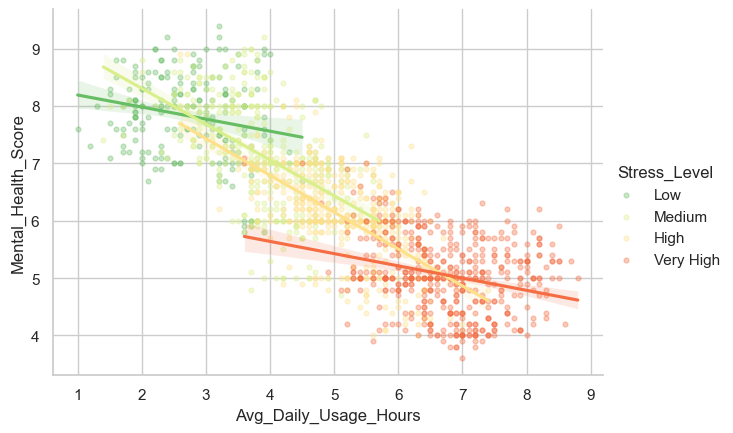

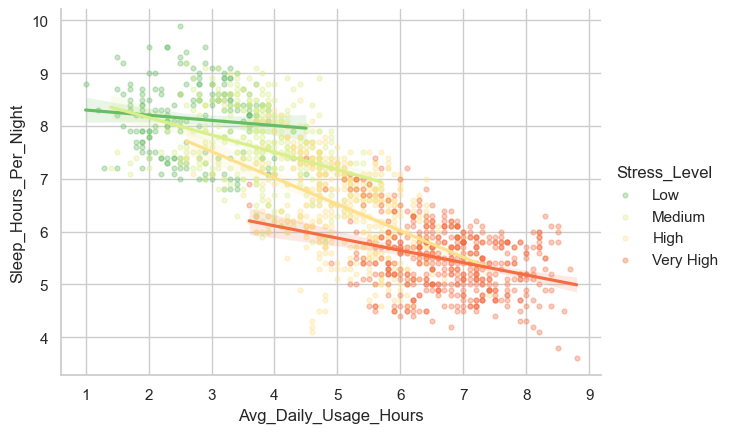

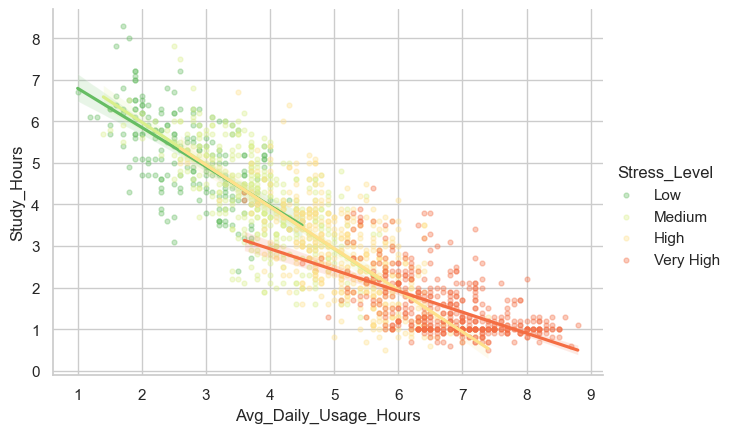

In [10]:
s = df.sample(1500, random_state=3)
for x, y_ in [("Avg_Daily_Usage_Hours", "Mental_Health_Score"), ("Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"), ("Avg_Daily_Usage_Hours", "Study_Hours")]:
    sns.lmplot(data=s, x=x, y=y_, hue=TARGET, hue_order=ORDER, palette="RdYlGn_r", height=4.5, aspect=1.4, scatter_kws={"alpha": .35, "s": 12})
    plt.show()

## 4d) Conventional EDA vs Tools

In [11]:
checks = pd.DataFrame({
    "pandas result": [
        int(df.duplicated().sum()),
        int(df.isna().sum().sum()),
        int((df["Physical_Activity_Hours"] == 0).sum()),
        int((df["Physical_Activity_Hours"] < 0).sum()),
        round(df[TARGET].value_counts(normalize=True).max() * 100, 1),
        df["Country"].nunique(),
        round(df[["Avg_Daily_Usage_Hours", "Daily_Unlocks"]].corr().iloc[0, 1], 3),
    ],
    "what ydata-profiling shows (fill in)": ["" for _ in range(7)],
}, index=["duplicate rows", "missing cells", "zeros in Physical_Activity_Hours", "NEGATIVE Physical_Activity_Hours (tool does not flag)",
          "largest class %", "Country unique values", "corr usage vs unlocks"])
display(checks)

,pandas result,what ydata-profiling shows (fill in)
duplicate rows,2.00,
missing cells,0.00,
zeros in Physical_Activity_Hours,13.00,
NEGATIVE Physical_Activity_Hours (tool does not flag),10.00,
largest class %,32.40,
Country unique values,111.00,
corr usage vs unlocks,0.96,


## 4e) Non-linear (polynomial) trends

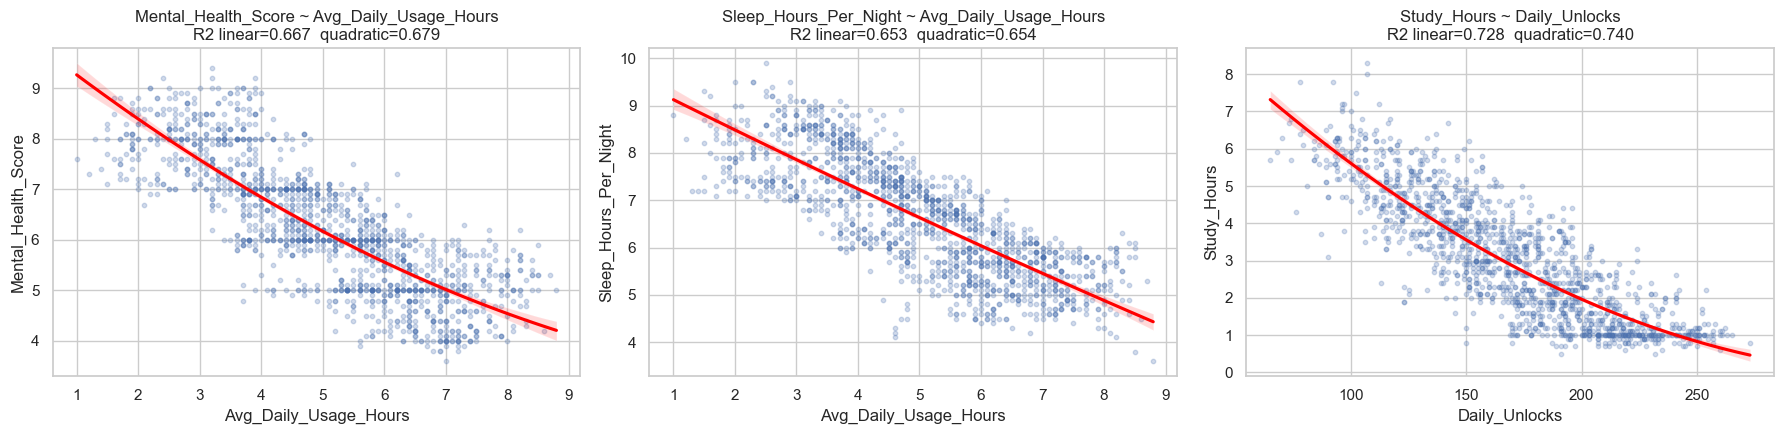

In [12]:
pairs = [("Avg_Daily_Usage_Hours", "Mental_Health_Score"), ("Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"), ("Daily_Unlocks", "Study_Hours")]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (x, y_) in zip(axes, pairs):
    sns.regplot(data=s, x=x, y=y_, order=2, scatter_kws={"alpha": .25, "s": 10}, line_kws={"color": "red"}, ax=ax)
    r2 = {}
    for deg in (1, 2):
        p = np.polyfit(df[x], df[y_], deg); r2[deg] = 1 - ((df[y_] - np.polyval(p, df[x])) ** 2).sum() / ((df[y_] - df[y_].mean()) ** 2).sum()
    ax.set_title(f"{y_} ~ {x}\nR2 linear={r2[1]:.3f}  quadratic={r2[2]:.3f}")
plt.tight_layout(); plt.show()